In [5]:
pip install dmba

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score


In [7]:
attr_df = pd.read_csv(r"C:\Users\arali\Desktop\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [8]:
attr_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [29]:
attr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
attr_df.isnull().any().any()

np.False_

In [11]:
# Drop ID-like column (not useful for prediction)
X = attr_df.drop(columns=['Attrition','EmployeeNumber'])  
y = attr_df['Attrition'].map({'Yes':1,'No':0})  # convert target to 0/1


In [30]:
summary_stats = attr_df.describe()
print("Summary statistics:")
print(summary_stats)


Summary statistics:
               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        60

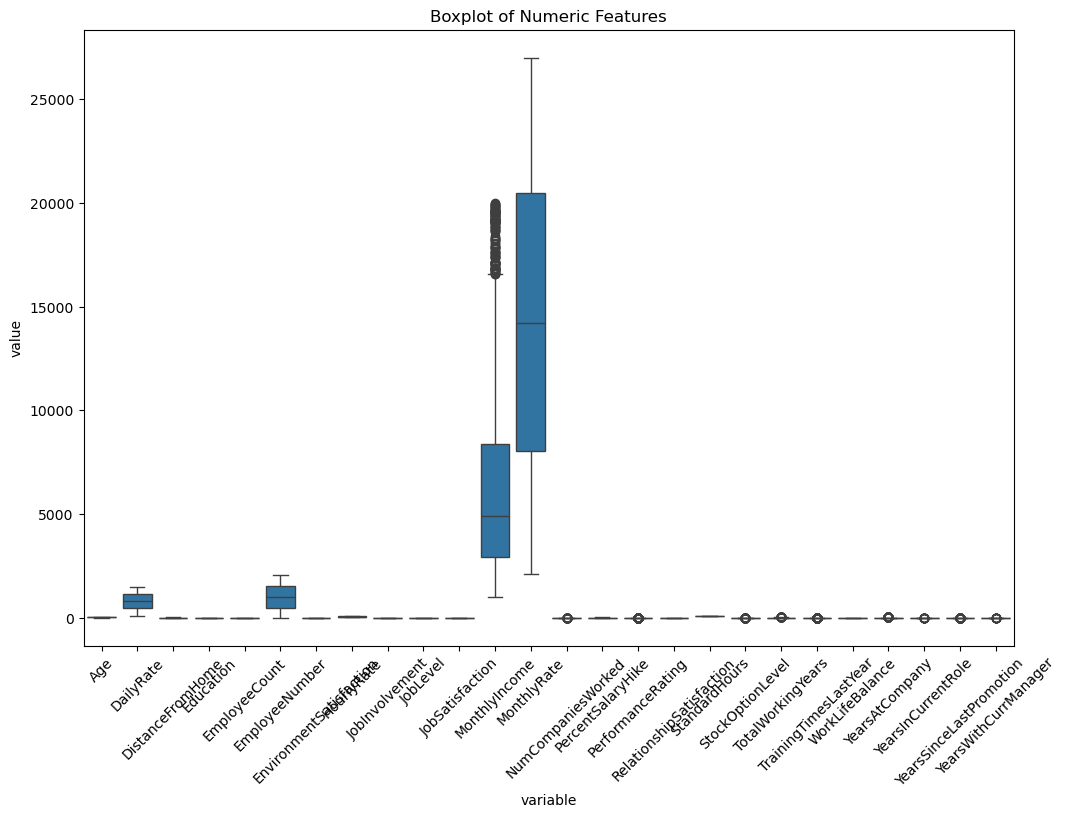

In [13]:
plt.figure(figsize=(12, 8))
sns.boxplot(x="variable", y="value", 
            data=attr_df.select_dtypes(include=['int64','float64']).melt())
plt.title('Boxplot of Numeric Features')
plt.xticks(rotation=45)
plt.show()


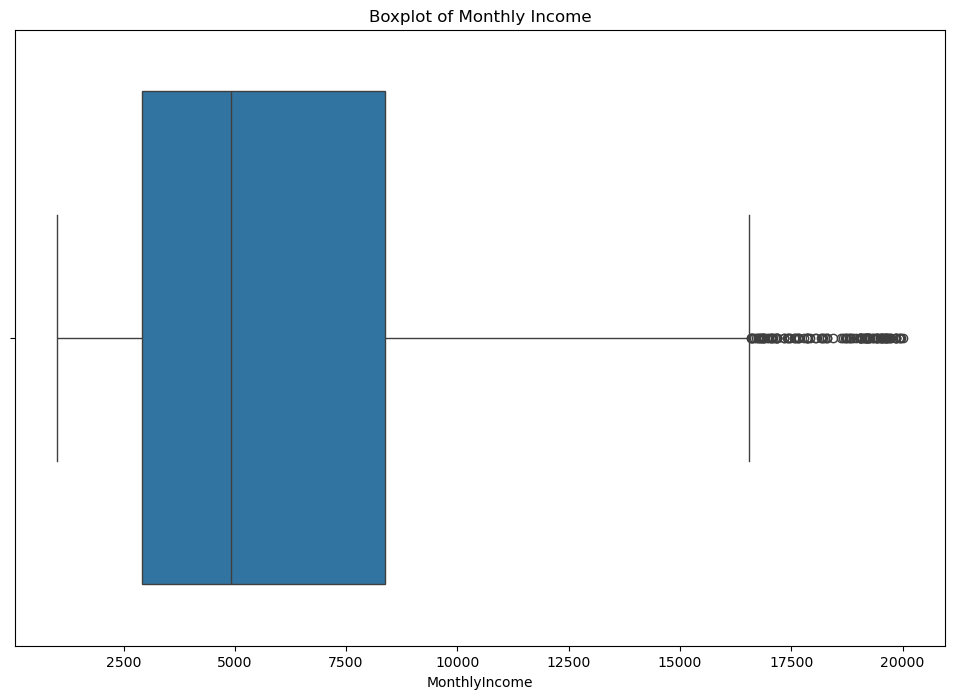

In [14]:
plt.figure(figsize=(12, 8))
sns.boxplot(x=attr_df['MonthlyIncome'])
plt.title('Boxplot of Monthly Income')
plt.show()


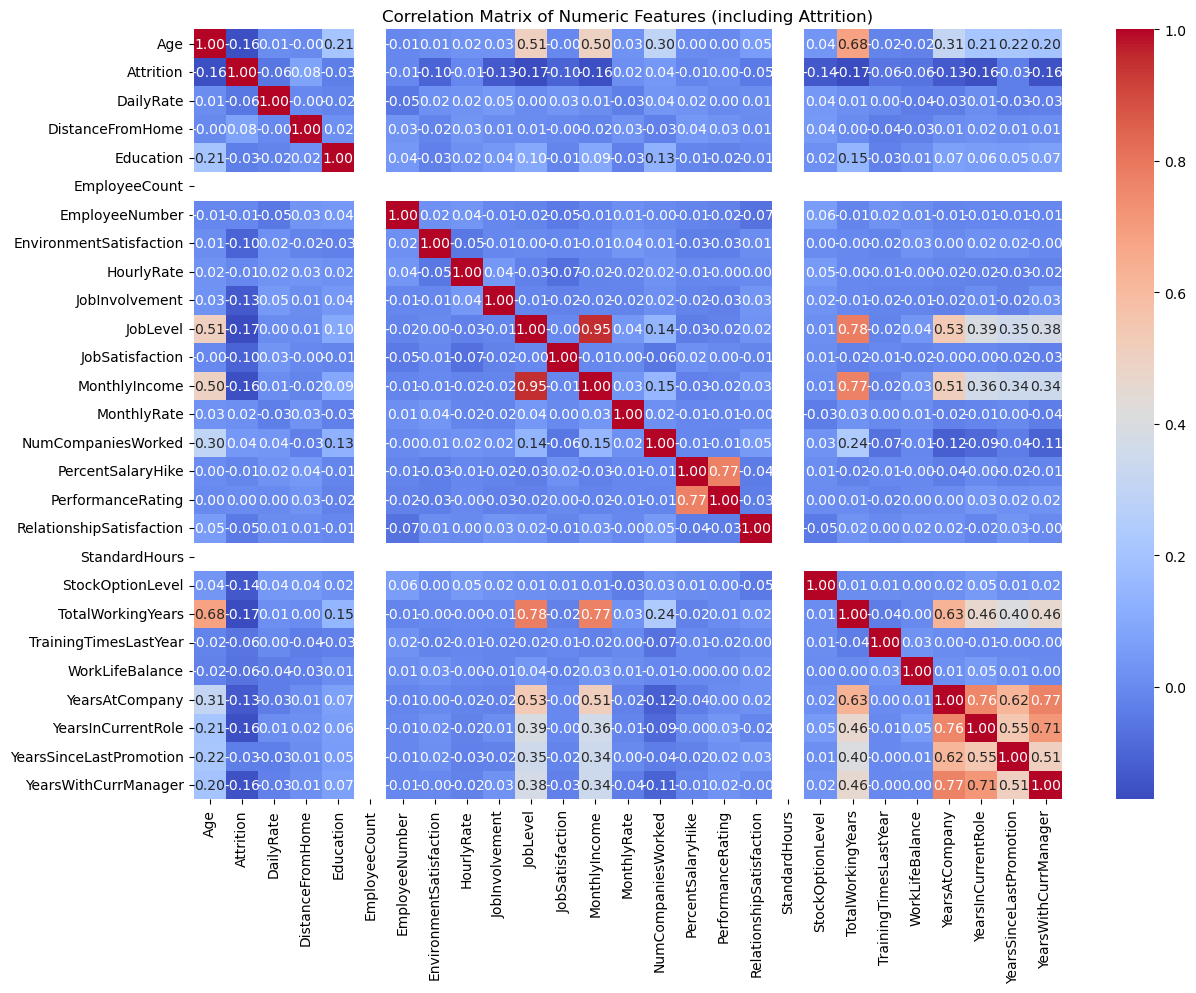

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Copy dataset
df_corr = attr_df.copy()

# Convert Attrition to numeric (Yes=1, No=0)
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})

# Select numeric columns only
numeric_df = df_corr.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Numeric Features (including Attrition)")
plt.show()


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)


In [17]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identify numeric vs categorical
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Pipelines
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor = ColumnTransformer([
    ('num', num_transformer, numeric_features),
    ('cat', cat_transformer, categorical_features)
])


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print("Logistic Regression Results:\n")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Results:

              precision    recall  f1-score   support

           0       0.92      0.80      0.86       309
           1       0.38      0.63      0.47        59

    accuracy                           0.77       368
   macro avg       0.65      0.71      0.66       368
weighted avg       0.83      0.77      0.79       368



In [19]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# ---- SVM Model ----
svm_pipeline = Pipeline([
    ('preprocessing', preprocessor),   # reuse your preprocessor from earlier
    ('clf', SVC(kernel='rbf', C=1, class_weight='balanced'))
])

# Train
svm_pipeline.fit(X_train, y_train)

# Predict
y_pred_svm = svm_pipeline.predict(X_test)

# Evaluate
print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))


SVM Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.88      0.90       309
           1       0.49      0.59      0.54        59

    accuracy                           0.84       368
   macro avg       0.71      0.74      0.72       368
weighted avg       0.85      0.84      0.84       368



### SVM Results – Analysis

**Metrics:**
- Class 0 (No Attrition):
  - Precision = 0.92, Recall = 0.88, F1 = 0.90 → Strong and balanced.
- Class 1 (Attrition):
  - Precision = 0.49, Recall = 0.59, F1 = 0.54 → Much better at capturing leavers than KNN or Random Forest.

**Overall:**
- Accuracy = 84% → Comparable to Random Forest, but more balanced across classes.
- Macro F1 = 0.72 → Significantly better than Random Forest (0.54).
- Weighted F1 = 0.84 → Good balanced performance overall.

**Interpretation:**
- SVM provides the best balance so far between detecting attrition and non-attrition.
- While precision for attrition is still modest (49%), recall is stronger (59%), meaning it catches more true leavers.
- Overall performance is more balanced than Logistic Regression and Random Forest.



In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Results:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Results:

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       309
           1       0.55      0.10      0.17        59

    accuracy                           0.84       368
   macro avg       0.70      0.54      0.54       368
weighted avg       0.80      0.84      0.79       368



### Random Forest Results – Analysis

**Metrics:**
- Class 0 (No Attrition):
  - Precision = 0.85, Recall = 0.98, F1 = 0.91 → Very strong at predicting employees who stay.
- Class 1 (Attrition):
  - Precision = 0.55, Recall = 0.10, F1 = 0.17 → Performs very poorly at detecting actual attrition cases.

**Overall:**
- Accuracy = 84% → Looks strong, but mainly due to majority class dominance.
- Macro F1 = 0.54 → Indicates imbalance in predictive ability across classes.
- Weighted F1 = 0.79 → Weighted by class sizes, still dominated by class 0.

**Interpretation:**
- Random Forest heavily favors the "No Attrition" class.
- Excellent recall for stayers (98%), but almost useless for attrition detection (10%).
- Accuracy is misleading here because of severe class imbalance.



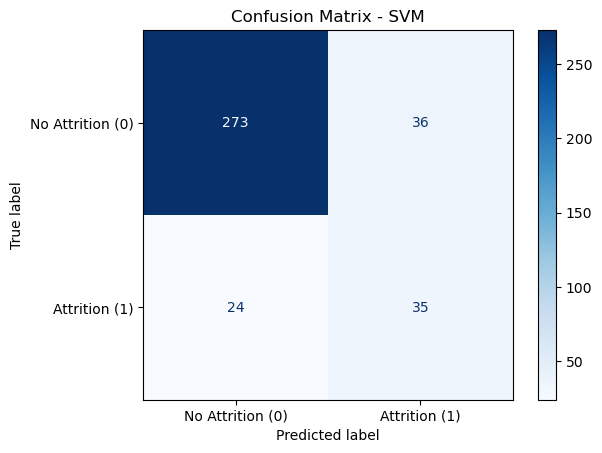

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Display with labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Attrition (0)', 'Attrition (1)']
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()


In [22]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"   # or set to the number of cores you want


KNN Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       309
           1       0.58      0.12      0.20        59

    accuracy                           0.85       368
   macro avg       0.72      0.55      0.56       368
weighted avg       0.81      0.85      0.80       368



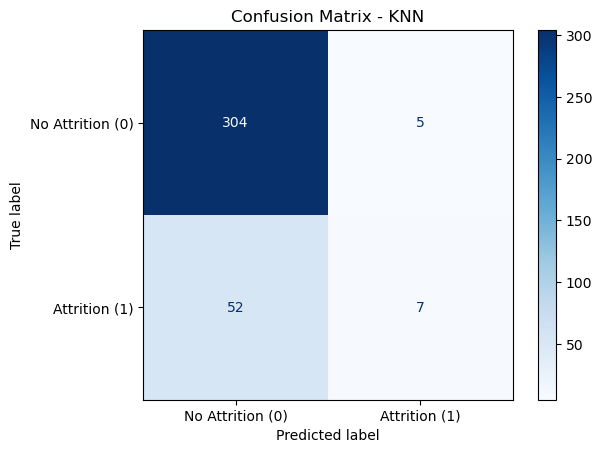

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---- KNN Model ----
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),   # reuse your preprocessor
    ('clf', KNeighborsClassifier(n_neighbors=5))  # default k=5
])

# Train
knn_pipeline.fit(X_train, y_train)

# Predict
y_pred_knn = knn_pipeline.predict(X_test)

# Evaluate
print("KNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                                  display_labels=['No Attrition (0)', 'Attrition (1)'])
disp_knn.plot(cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.show()


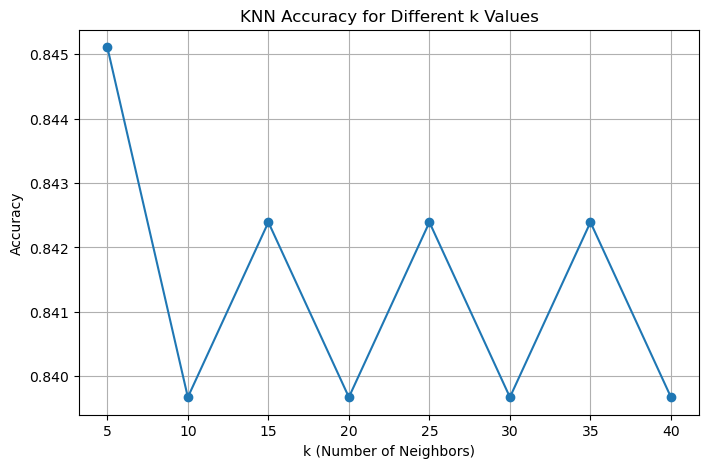

Best k: 5 with accuracy: 0.8451


In [24]:
k_values = [5, 10, 15, 20, 25, 30, 35, 40]
scores = []

for k in k_values:
    knn_pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    knn_pipeline.fit(X_train, y_train)            # Train
    y_pred = knn_pipeline.predict(X_test)         # Predict
    accuracy = accuracy_score(y_test, y_pred)     # Accuracy
    scores.append(accuracy)

# Plot accuracy vs k
plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker='o')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different k Values')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Print best k
best_k = k_values[scores.index(max(scores))]
print(f"Best k: {best_k} with accuracy: {max(scores):.4f}")


Training final KNN model with best k = 5

KNN Classification Report (Best k):

              precision    recall  f1-score   support

           0       0.85      0.98      0.91       309
           1       0.58      0.12      0.20        59

    accuracy                           0.85       368
   macro avg       0.72      0.55      0.56       368
weighted avg       0.81      0.85      0.80       368



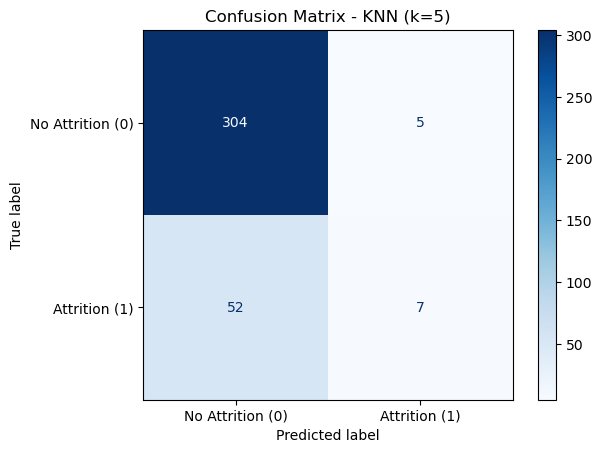

In [25]:
# ---- Final KNN Model using Best k ----

# Best k from tuning step
best_k = k_values[scores.index(max(scores))]
print(f"Training final KNN model with best k = {best_k}")

# Build pipeline with best k
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

# Train
knn_pipeline.fit(X_train, y_train)

# Predict
y_pred_knn = knn_pipeline.predict(X_test)

# Evaluate
print("\nKNN Classification Report (Best k):\n")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                                  display_labels=['No Attrition (0)', 'Attrition (1)'])
disp_knn.plot(cmap="Blues")
plt.title(f"Confusion Matrix - KNN (k={best_k})")
plt.show()


 ### KNN Results Analysis

**Confusion Matrix (KNN):**
- True Negatives (TN = 304): Correctly predicted "No Attrition"
- False Positives (FP = 5): Predicted "Attrition" but employee stayed
- False Negatives (FN = 52): Predicted "No Attrition" but employee left
- True Positives (TP = 7): Correctly predicted "Attrition"

**Metrics:**
- Class 0 (No Attrition):
  - Precision = 0.85
  - Recall = 0.98
  - F1 = 0.91
- Class 1 (Attrition):
  - Precision = 0.58
  - Recall = 0.12
  - F1 = 0.20
- Overall Accuracy = 0.85

**Interpretation:**
- Model is biased towards predicting "No Attrition".
- Excellent at identifying stayers (98% recall).
- Very poor at detecting leavers (only 12% recall).
- Accuracy looks high but is misleading due to class imbalance

Naive Bayes Results:

              precision    recall  f1-score   support

           0       0.92      0.68      0.78       309
           1       0.29      0.68      0.41        59

    accuracy                           0.68       368
   macro avg       0.60      0.68      0.59       368
weighted avg       0.82      0.68      0.72       368

Accuracy: 0.6821


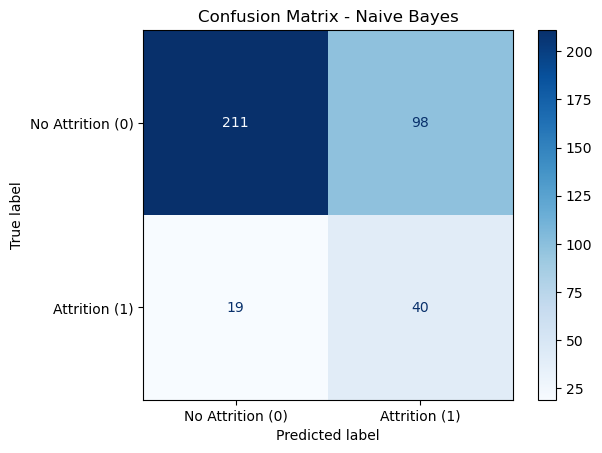

In [26]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---- Naive Bayes Model ----
nb_pipeline = Pipeline([
    ('preprocessing', preprocessor),   # use the same preprocessor as before
    ('clf', GaussianNB())
])

# Train
nb_pipeline.fit(X_train, y_train)

# Predict
nb_pred = nb_pipeline.predict(X_test)

# Evaluate
nb_accuracy = accuracy_score(y_test, nb_pred)
print("Naive Bayes Results:\n")
print(classification_report(y_test, nb_pred))
print(f"Accuracy: {nb_accuracy:.4f}")

# Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_pred)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb,
                                 display_labels=['No Attrition (0)', 'Attrition (1)'])
disp_nb.plot(cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


### Naive Bayes Model Results

**Accuracy:** 68.2%

**Classification Report:**

- **Class 0 (No Attrition):**
  - Precision: 0.92
  - Recall: 0.68
  - F1-score: 0.78  

- **Class 1 (Attrition):**
  - Precision: 0.29
  - Recall: 0.68
  - F1-score: 0.41  

**Analysis:**
- The model achieves a moderate accuracy of ~68%.
- It performs very well at correctly identifying employees who stay (high precision for class 0).
- For predicting attrition (class 1), recall is relatively strong (0.68), meaning it captures many of the actual leavers.
- However, precision for attrition is quite low (0.29), indicating a high rate of false positives.
- Overall, Naive Bayes is useful for flagging potential at-risk employees but may over-predict attrition.


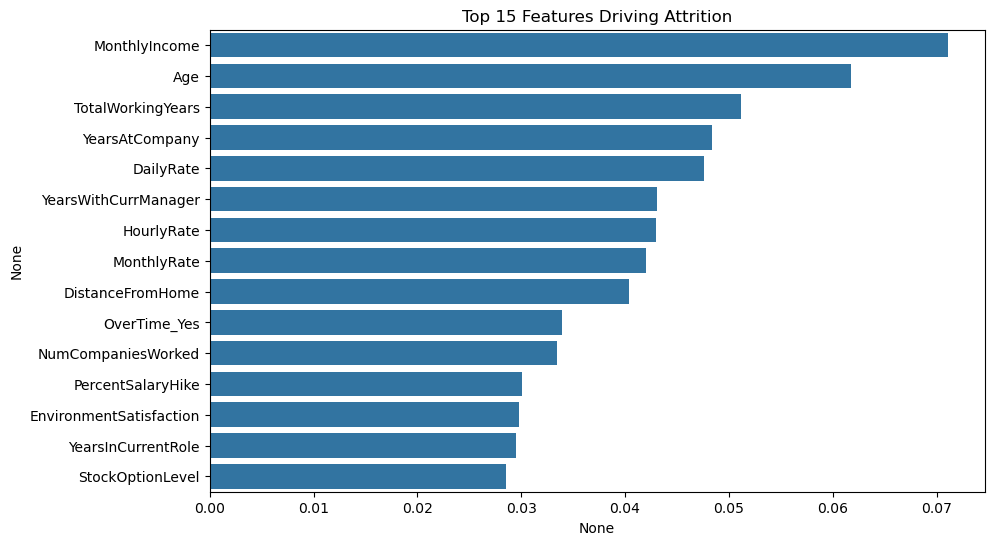

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

rf_model = rf_pipeline.named_steps['clf']
ohe = preprocessor.named_transformers_['cat']
cat_cols = ohe.get_feature_names_out(categorical_features)
all_features = numeric_features + list(cat_cols)

feat_imp = pd.Series(rf_model.feature_importances_, index=all_features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp[:15], y=feat_imp.index[:15])
plt.title("Top 15 Features Driving Attrition")
plt.show()


## 🔎 Model Comparison – Employee Attrition Prediction

| Model                  | Accuracy | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) | Key Observation |
|-------------------------|----------|----------------------|------------------|--------------|-----------------|
| **KNN**                | 0.85     | 0.58                 | 0.12             | 0.20         | Very poor at detecting attrition (severe bias toward "No Attrition"). |
| **Logistic Regression**| 0.77     | 0.38                 | 0.63             | 0.47         | Best recall for attrition, but low precision (many false alarms). |
| **Random Forest**      | 0.84     | 0.55                 | 0.10             | 0.17         | Excellent for stayers, but almost useless for attrition detection. |
| **SVM**                | 0.84     | 0.49                 | 0.59             | 0.54         | Best balance overall between precision and recall for attrition. |
| **Naive Bayes**        | 0.68     | 0.29                 | 0.68             | 0.41         | Lower accuracy, but surprisingly good at catching leavers (high recall). |

---



> “In this part, we compared five different models to predict whether employees will leave the company or not.  
>   
> The **KNN model** looks accurate overall, but it mostly predicts that employees will stay — so it misses many who actually leave.  
>   
> The **Logistic Regression model** catches the most employees who are likely to leave (highest recall, 63%), but it gives a lot of false positives.  
>   
> The **Random Forest model** performs well for predicting employees who stay, but struggles to identify those who leave.  
>   
> The **SVM model** performs the best overall — it has a good balance between precision and recall, meaning it finds leavers fairly well without too many false alarms.  
>   
> Finally, the **Naive Bayes model** has a lower accuracy of about **68%**, but it’s very good at detecting employees who actually leave (recall = 68%).  
> This means that even though it’s not as accurate overall, it’s very sensitive to attrition cases — which can be useful if the goal is to catch potential leavers early.  
>   
> In summary, each model has strengths and weaknesses:  
> - **Random Forest** and **KNN** are good for overall accuracy.  
> - **Logistic Regression** and **Naive Bayes** are better for finding leavers.  
> - **SVM** provides the most balanced and dependable performance.”
  

